Learning Objectives
- OpenAI GPT-4V 모델 이용해서 비정형 이미지 데이터로부터 정형 필드 파싱해보기

In [ ]:
%pip install llama-index-multi-modal-llms-openai
%pip install llama-index-multi-modal-llms-replicate
%pip install llama-index-readers-file

Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [llama-index-multi-modal-llms-replicate]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os

from dotenv import load_dotenv

load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
pinecone_api_key = os.getenv("PINECONE_API_KEY")

In [2]:
from pathlib import Path

def image_dir_path(dir_name: str, base_dir="./images") -> Path:
    base_dir = Path(base_dir)
    return base_dir / dir_name

In [3]:
restaurant_dir = image_dir_path("restaurant_images")

# restaurant_dir = Path("./images/restaurant_images")  # 또는 원하는 작업 디렉토리 기준 경로

if not restaurant_dir.exists():
    restaurant_dir.mkdir(parents=True, exist_ok=True)


In [4]:
def image_file_path(dir_path, filename: str) -> Path:
    return dir_path / filename

In [6]:
res_file_path = image_file_path(restaurant_dir, "fried_chicken.png")
res_file_path

PosixPath('images/restaurant_images/fried_chicken.png')

In [ ]:
res_file_path = image_file_path(restaurant_dir, "fried_chicken.png")

!curl -L "https://docs.google.com/uc?export=download&id=1GlqcNJhGGbwLKjJK1QJ_nyswCTQ2K2Fq" -o {output_file}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1001k  100 1001k    0     0   347k      0  0:00:02  0:00:02 --:--:--  852k


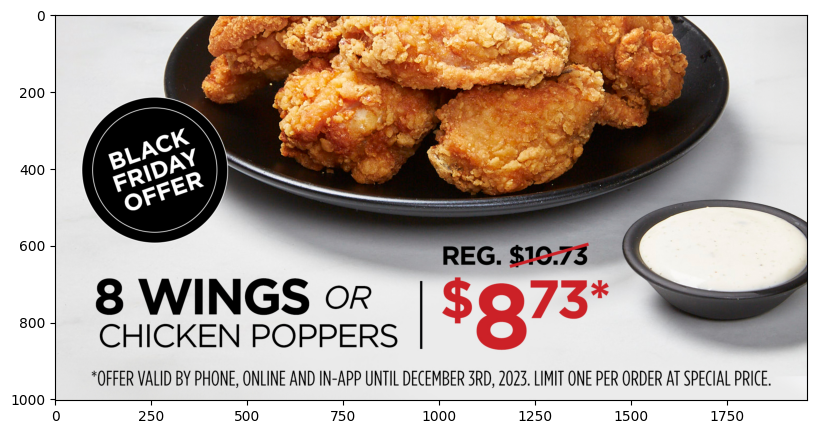

In [80]:
from PIL import Image
import matplotlib.pyplot as plt

imageUrl = res_file_path # "./images/restaurant_images/fried_chicken.png"
image = Image.open(imageUrl).convert("RGB")

plt.figure(figsize=(16, 5))
plt.imshow(image)

In [ ]:
from pydantic import BaseModel

class Restaurant(BaseModel):
    # 파싱 클래스 설명넣기
    """Data model for an restaurant."""
    # 파싱 필드 정의하기
    restaurant: str
    food: str
    discount: str
    price: str
    rating: str
    review: str

In [ ]:
# !pip install llama-index-readers-file

In [62]:
from llama_index.core import SimpleDirectoryReader
from llama_index.core.base.llms.types import ImageBlock

def load_image_blocks(image_dir: str) -> list[ImageBlock]:
    raw_docs = SimpleDirectoryReader(image_dir).load_data()
    blocks: list[ImageBlock] = []

    for doc in raw_docs:
        path = doc.image_path or doc.metadata.get("file_path")
        if not path:
            continue
        blocks.append(ImageBlock(path=path))

    return blocks

In [68]:
from llama_index.multi_modal_llms.openai import OpenAIMultiModal
from llama_index.core import SimpleDirectoryReader
from llama_index.core.base.llms.types import ImageBlock

image_documents = load_image_blocks(restaurant_dir)

openai_mm_llm = OpenAIMultiModal(
    model="gpt-4o-mini", max_new_tokens=1000
)

/var/folders/95/t8symb5521g2916cz4qtrsjc0000gn/T/ipykernel_25483/321258509.py:7: DeprecationWarning: Call to deprecated class OpenAIMultiModal. (The package has been deprecated and will no longer be maintained. Please use llama-index-llms-openai (preferably the Responses API) instead. See Multi Modal LLMs documentation for a complete guide on migration: https://docs.llamaindex.ai/en/stable/understanding/using_llms/using_llms/#multi-modal-llms) -- Deprecated since version 0.5.2.
  openai_mm_llm = OpenAIMultiModal(


In [69]:
from llama_index.core.program import MultiModalLLMCompletionProgram
from llama_index.core.output_parsers import PydanticOutputParser

#파싱 인스트럭션
prompt_template_str = """\
    can you summarize what is in the image\
    and return the answer with json format \
"""
openai_program = MultiModalLLMCompletionProgram.from_defaults(
    output_parser=PydanticOutputParser(Restaurant),
    image_documents=image_documents,
    prompt_template_str=prompt_template_str,
    multi_modal_llm=openai_mm_llm,
    verbose=True,
)

In [70]:
response = openai_program()
for res in response:
    print(res)

2026-03-05 12:54:54,906 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


> Raw output: {
  "restaurant": "Not specified",
  "food": "8 Wings or Chicken Poppers",
  "discount": "Black Friday Offer",
  "price": "$8.73 (Regular: $10.73)",
  "rating": "Not specified",
  "review": "Offer valid by phone, online, and in-app until December 3rd, 2023. Limit one per order at special price."
}
('restaurant', 'Not specified')
('food', '8 Wings or Chicken Poppers')
('discount', 'Black Friday Offer')
('price', '$8.73 (Regular: $10.73)')
('rating', 'Not specified')
('review', 'Offer valid by phone, online, and in-app until December 3rd, 2023. Limit one per order at special price.')


In [ ]:
# 아마존 상품
amazon_dir_path = image_dir_path("amazon_images")
if not amazon_dir_path.exists():
    Path.mkdir(amazon_dir_path)

In [83]:
!curl -L "https://docs.google.com/uc?export=download&id=1p1Y1qAoM68eC4sAvvHaiJyPhdUZS0Gqb" -o {amazon_dir_path}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0Warning: Failed to open the file images/amazon_images: Is a directory
  0 1400k    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
curl: (56) Failure writing output to destination, passed 1369 returned 4294967295


In [ ]:
image_file_path(amazon_dir_path, "amazon.png")

PosixPath('images/amazon_images/amazon.png')

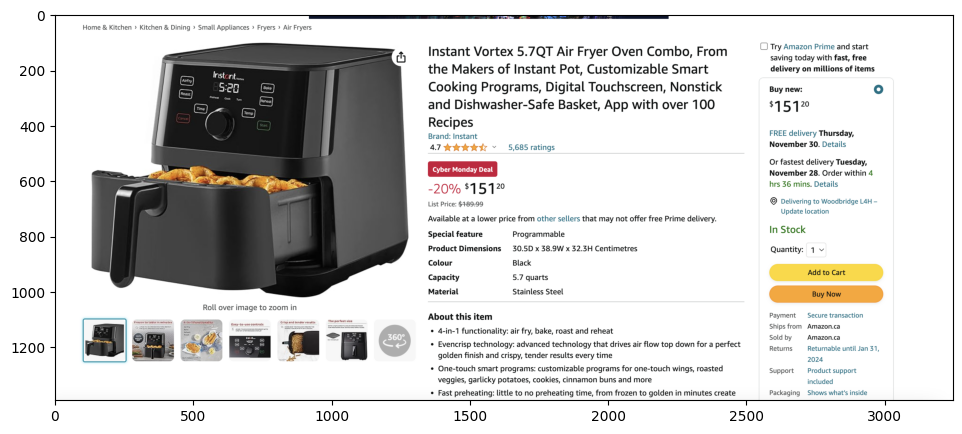

In [ ]:
amazon_img_path = image_file_path(amazon_dir_path, "amazon.png")
image = Image.open(amazon_img_path).convert("RGB")

plt.figure(figsize=(16, 5))
plt.imshow(image)

In [86]:
from pydantic import BaseModel

class Product(BaseModel):
    # 클래스 디스크립션 작성
    """Data model for a Amazon Product."""

    title: str
    category: str
    discount: str
    inventory: str
    description: str
    # 파싱 필드 정의

In [92]:
amazon_image_documents = load_image_blocks(amazon_dir_path)

prompt_template_str = """\
    can you summarize what is in the image\
    and return the answer with json format \
"""
openai_program_amazon = MultiModalLLMCompletionProgram.from_defaults(
    output_parser=PydanticOutputParser(Product),
    image_documents=amazon_image_documents,
    prompt_template_str=prompt_template_str,
    multi_modal_llm=openai_mm_llm,
    verbose=True,
)

In [90]:
response = openai_program_amazon()
for res in response:
    print(res)

2026-03-05 13:02:13,105 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


> Raw output: {
  "title": "Instant Vortex 5.7QT Air Fryer Oven Combo",
  "category": "Home & Kitchen > Kitchen & Dining > Small Appliances > Fryers > Air Fryers",
  "discount": "-20%",
  "inventory": "In Stock",
  "description": "The Instant Vortex 5.7QT Air Fryer Oven Combo features customizable smart cooking programs, a digital touchscreen, a nonstick and dishwasher-safe basket, and an app with over 100 recipes. It offers 4-in-1 functionality: air fry, bake, roast, and reheat, with advanced Evencrisp technology for perfect results."
}
('title', 'Instant Vortex 5.7QT Air Fryer Oven Combo')
('category', 'Home & Kitchen > Kitchen & Dining > Small Appliances > Fryers > Air Fryers')
('discount', '-20%')
('inventory', 'In Stock')
('description', 'The Instant Vortex 5.7QT Air Fryer Oven Combo features customizable smart cooking programs, a digital touchscreen, a nonstick and dishwasher-safe basket, and an app with over 100 recipes. It offers 4-in-1 functionality: air fry, bake, roast, and 

In [97]:
instagram_dir_path = image_dir_path("instagram_images")
if not instagram_dir_path.exists():
    Path.mkdir(instagram_dir_path)

In [100]:
instagram_file_path = image_file_path(instagram_dir_path, "jordan.png")

!curl -L "https://docs.google.com/uc?export=download&id=12ZpBBFkYu-jzz1iz356U5kMikn4uN9ww" -o {instagram_file_path}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 2658k  100 2658k    0     0   314k      0  0:00:08  0:00:08 --:--:--  485k:00:04  0:00:12  231k


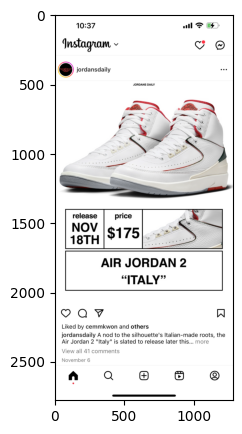

In [101]:
from PIL import Image
import matplotlib.pyplot as plt

imageUrl = instagram_file_path
image = Image.open(imageUrl).convert("RGB")

plt.figure(figsize=(16, 5))
plt.imshow(image)

In [102]:
from pydantic import BaseModel


class InsAds(BaseModel):
    # 파싱 클래스 디스크립션 작성
    """Data model for a Instagram Ads."""

    account: str
    brand: str
    product: str
    price: str
    comments: str
    # 파싱 희망 필드 작성

In [104]:
ins_image_documents = load_image_blocks(instagram_dir_path)

In [105]:


prompt_template_str = """\
    can you summarize what is in the image\
    and return the answer with json format \
"""
openai_program_ins = MultiModalLLMCompletionProgram.from_defaults(
    output_parser=PydanticOutputParser(InsAds),
    image_documents=ins_image_documents,
    prompt_template_str=prompt_template_str,
    multi_modal_llm=openai_mm_llm,
    verbose=True,
)


response = openai_program_ins()
for res in response:
    print(res)

2026-03-05 13:12:31,143 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


> Raw output: {
  "account": "jordansdaily",
  "brand": "Air Jordan",
  "product": "Air Jordan 2 \"Italy\"",
  "price": "$175",
  "comments": "A nod to the silhouette's Italian-made roots, the Air Jordan 2 \"Italy\" is slated to release later this month."
}
('account', 'jordansdaily')
('brand', 'Air Jordan')
('product', 'Air Jordan 2 "Italy"')
('price', '$175')
('comments', 'A nod to the silhouette\'s Italian-made roots, the Air Jordan 2 "Italy" is slated to release later this month.')
